In [10]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [12]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [13]:
df['age'] = df['age'].fillna(df['age'].mean())
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

In [14]:
df.drop(['deck'], axis=1, inplace=True)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  embark_town  891 non-null    str     
 12  alive        891 non-null    str     
 13  alone        891 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), str(5)
memory usage: 79.4 KB


survived: 0 outliers (Z-score > 3 bounds: -1.08 - 1.84)
pclass: 0 outliers (Z-score > 3 bounds: -0.20 - 4.82)
age: 7 outliers (Z-score > 3 bounds: -9.31 - 68.71)
sibsp: 30 outliers (Z-score > 3 bounds: -2.79 - 3.83)
parch: 15 outliers (Z-score > 3 bounds: -2.04 - 2.80)
fare: 20 outliers (Z-score > 3 bounds: -116.88 - 181.28)


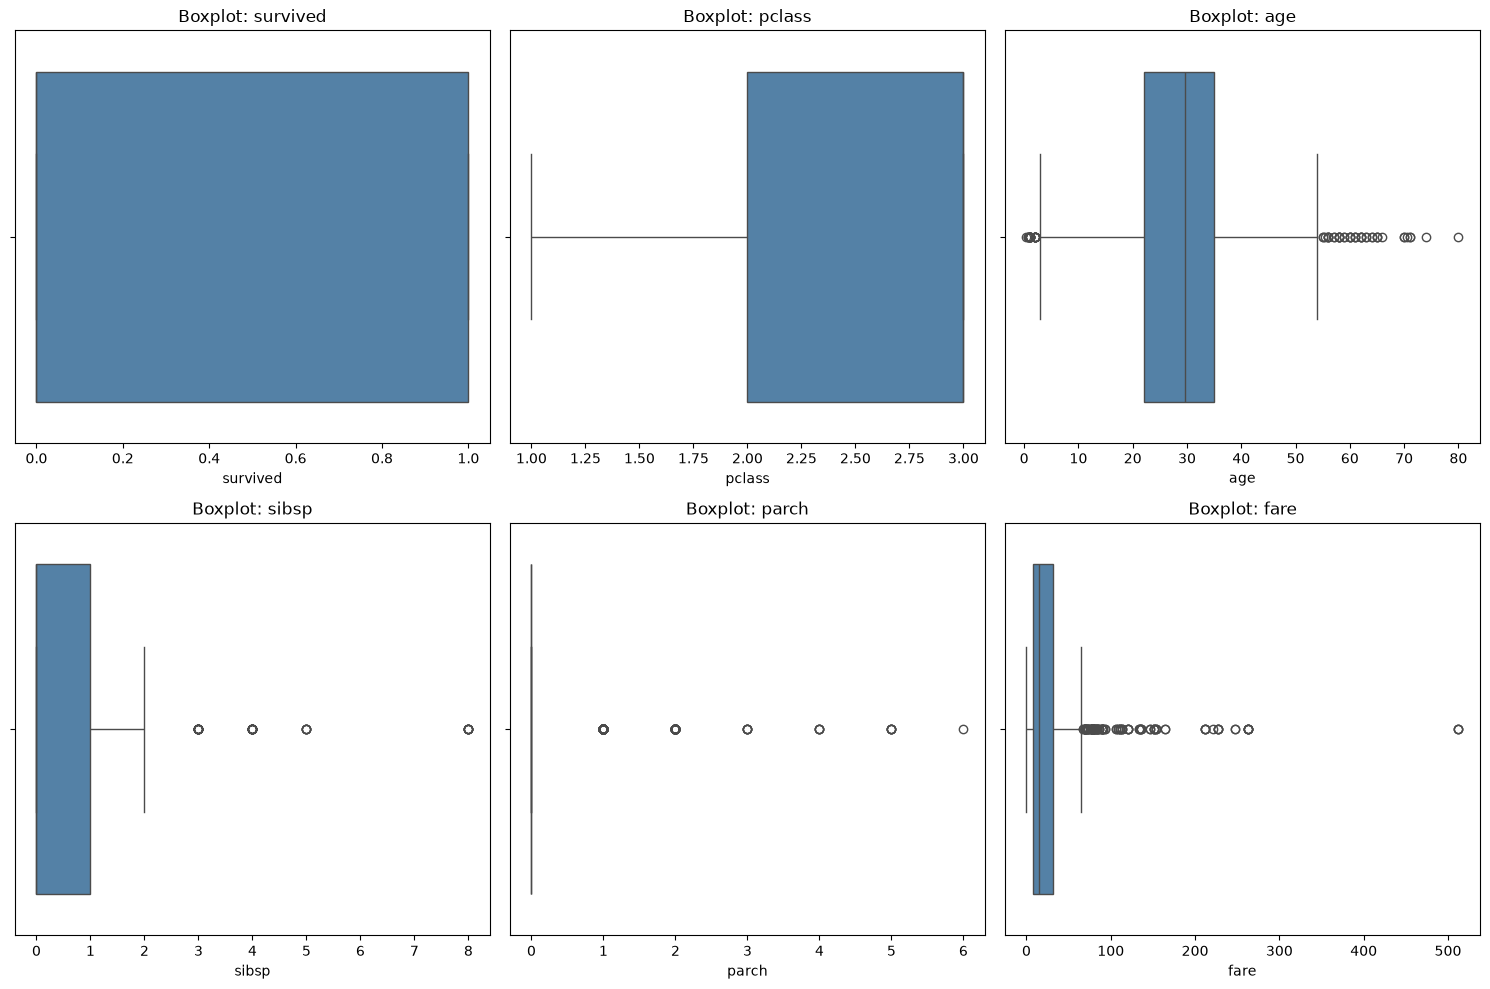

In [21]:
from scipy import stats

numerical_cols = df.select_dtypes(include=[np.number]).columns
z_outlier_summary = {}

for col in numerical_cols:
    z_scores = stats.zscore(df[col], nan_policy='omit')
    outliers = df[np.abs(z_scores) > 3]
    
    mean_val = df[col].mean()
    std_val = df[col].std()
    lower_bound = mean_val - 3 * std_val
    upper_bound = mean_val + 3 * std_val
    
    z_outlier_summary[col] = {
        'count': len(outliers),
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }
    print(f"{col}: {len(outliers)} outliers (Z-score > 3 bounds: {lower_bound:.2f} - {upper_bound:.2f})")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x=col, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'Boxplot: {col}')

plt.tight_layout()
plt.show()

In [16]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
import plotly.express as px

fig = px.scatter(
    df,
    x='age',
    y='fare',
    color='survived',
    symbol='pclass',
    hover_data=['sex', 'class', 'embark_town'],
    title='Titanic: Age vs Fare by Survival and Class',
    labels={'age': 'Age', 'fare': 'Fare', 'survived': 'Survived', 'pclass': 'Passenger Class'}
)
fig.show()

### Key Insights & Data Story: Titanic Dataset

Our initial exploration of the Titanic dataset reveals a structured shape of **891 rows** and **15 columns** featuring a mix of numerical, categorical, and boolean types. 
While columns like **`age`** and **`embarked`** have been successfully cleaned and fully imputed to 891 non-null values, the **`deck`** column remains highly incomplete with only **203 non-null entries** (~77% missing data).
The `age` column is now properly formatted as a float, allowing it to be represented alongside key metrics like **`fare`**, which is heavily right-skewed with an average of **$32.20** and a maximum of over **$512**. 
Overall, the training subset features a baseline survival rate of **38.4%**, and addressing the sparse `deck` feature remains our primary pre-modeling challenge.